In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
import sklearn
from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from datetime import datetime

In [ ]:
# Wczytanie pliku z czystymi danymi do Dataframe z separatorem jako średnik
df = pd.read_csv("otodom_housing_pages_model_ready.csv")

In [3]:
# Pogląd na pierwsze pięć rzędów danych
df.head()

,cena,pokoje,powierzchnia_m2,pietro,dzielnica,miasto,region
0,898000,2,"50,3",10,praga-poludnie,warszawa,mazowieckie
1,865000,2,"48,41",2,targowek,warszawa,mazowieckie
2,799000,3,"42,5",6,praga-poludnie,warszawa,mazowieckie
3,961234,3,"53,9",0,mokotow,warszawa,mazowieckie
4,790000,3,56,3,ursus,warszawa,mazowieckie


In [4]:
# Sprawdzanie czy istnieją puste wartości
df.isna().sum()

cena               0
pokoje             0
powierzchnia_m2    0
pietro             0
dzielnica          0
miasto             0
region             0
dtype: int64

In [5]:
# Informacje na temat Dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45180 entries, 0 to 45179
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cena             45180 non-null  int64 
 1   pokoje           45180 non-null  int64 
 2   powierzchnia_m2  45180 non-null  object
 3   pietro           45180 non-null  int64 
 4   dzielnica        45180 non-null  object
 5   miasto           45180 non-null  object
 6   region           45180 non-null  object
dtypes: int64(3), object(4)
memory usage: 2.4+ MB


In [ ]:
# Przypisanie datatype float dla powierzchnia_m2
df["powierzchnia_m2"] = df["powierzchnia_m2"].astype(float)

# Sprawdzenie, czy nie występują absurdalne wartości
print("\nTop 10 największych powierzchni:")
print(df.nlargest(10, 'powierzchnia_m2'))


Top 10 największych powierzchni:
          cena  pokoje  powierzchnia_m2  pietro              dzielnica  \
19505   406000       2        406000.00       1                 zachod   
25951   820000       4         11452.00       1            srodmiescie   
37160   749000       4         10096.00       4               grunwald   
8710    560349       3          8975.64       0                polesie   
17644   499000       2          4397.00       2                 polnoc   
29351  2850000       8          1017.50       1  centrum / srodmiescie   
35588  2850000       8          1017.50       1  centrum / srodmiescie   
29933  1850000       8           374.00       1            srodmiescie   
41900   340000       2           337.74       6        kalinowszczyzna   
12152  5800000      10           300.00       0              fabryczna   

          miasto              region  
19505   szczecin  zachodniopomorskie  
25951   katowice             slaskie  
37160     poznan       wielkopolsk

In [7]:
# Usuwanie absurdalnych powierzchni (>400 m²)
df = df[df['powierzchnia_m2'] <= 400].copy()

print("\nTop 10 największych powierzchni po wyczyszczeniu:")
print(df.nlargest(10, 'powierzchnia_m2'))


Top 10 największych powierzchni po wyczyszczeniu:
           cena  pokoje  powierzchnia_m2  pietro  \
29933   1850000       8           374.00       1   
41900    340000       2           337.74       6   
12152   5800000      10           300.00       0   
25964   2435000       1           296.58       1   
1520    5352859       5           296.00       1   
3320    2800000       6           283.00       0   
36871   2800000       9           283.00       0   
33350   1050000       6           280.00       1   
38889  11000000       6           280.00       0   
42892   3100000       1           278.49       1   

                             dzielnica    miasto          region  
29933                      srodmiescie    kielce  swietokrzyskie  
41900                  kalinowszczyzna    lublin       lubelskie  
12152                        fabryczna   wroclaw    dolnoslaskie  
25964  osiedle paderewskiego-muchowiec  katowice         slaskie  
1520                           wilanow  w

In [8]:
# Sprawdzanie ekstremalnych cen

print("Analiza rozkładu cen")

# Rozkład po przedziałach cenowych
print("\nPrzedział cenowy")

bins = [
    (0, 300000, "< 300k"),
    (300000, 500000, "300k-500k"),
    (500000, 750000, "500k-750k"),
    (750000, 1000000, "750k-1M"),
    (1000000, 1500000, "1M-1.5M"),
    (1500000, 2000000, "1.5M-2M"),
    (2000000, 3000000, "2M-3M"),
    (3000000, 5000000, "3M-5M"),
    (5000000, 10000000, "5M-10M"),
    (10000000, float('inf'), "> 10M")
]

for low, high, label in bins:
    count = ((df['cena'] >= low) & (df['cena'] < high)).sum()
    pct = count / len(df) * 100
    print(f"{label:15s}: {count:5d} mieszkań ({pct:5.2f}%)")

# Top 20 najdroższych mieszkań
print("\nTop 20 najdroższych mieszkań")
top_20 = df.nlargest(20, 'cena')[['cena', 'pokoje', 'powierzchnia_m2', 'pietro', 'miasto', 'dzielnica']]
print(top_20.to_string(index=False))

Analiza rozkładu cen

Przedział cenowy
< 300k         :  3227 mieszkań ( 7.14%)
300k-500k      : 14514 mieszkań (32.13%)
500k-750k      : 15742 mieszkań (34.85%)
750k-1M        :  6596 mieszkań (14.60%)
1M-1.5M        :  3153 mieszkań ( 6.98%)
1.5M-2M        :  1040 mieszkań ( 2.30%)
2M-3M          :   612 mieszkań ( 1.35%)
3M-5M          :   233 mieszkań ( 0.52%)
5M-10M         :    48 mieszkań ( 0.11%)
> 10M          :     8 mieszkań ( 0.02%)

Top 20 najdroższych mieszkań
    cena  pokoje  powierzchnia_m2  pietro   miasto    dzielnica
34500000       4           126.74      10   krakow   grzegorzki
19000000       5           205.47      10 warszawa  srodmiescie
14500000       4           165.00      10 warszawa  srodmiescie
12900000       4           274.05       1 warszawa  srodmiescie
12500000       4           162.00      10 warszawa  srodmiescie
11000000       4           160.00      10 warszawa  srodmiescie
11000000       6           280.00       0   gdansk    jelitkowo
10650000 

In [9]:
# Usunięcie ekstremalnych wartości
# Powyżej tej ceny mieszkania przeważnie nie są ważne dla przeciętnego użytkownika
# Te mieszkania to ultraluksusowe mieszkania, które cenowo cięzko zmierzyć dokładnie.
df = df[df['cena'] <= 3000000].copy()

In [10]:
# Ogólna analiza danych w Dataframie
df.describe(include="all")

,cena,pokoje,powierzchnia_m2,pietro,dzielnica,miasto,region
count,4.489200e+04,44892.000000,44892.000000,44892.000000,44892,44892,44892
unique,NaN,NaN,NaN,NaN,404,20,15
top,NaN,NaN,NaN,NaN,srodmiescie,poznan,slaskie
freq,NaN,NaN,NaN,NaN,5708,3263,5621
mean,6.517064e+05,2.591932,55.935829,2.567295,NaN,NaN,NaN
std,3.678884e+05,0.924202,21.628516,2.333778,NaN,NaN,NaN
min,5.500000e+04,1.000000,8.540000,0.000000,NaN,NaN,NaN
25%,4.284695e+05,2.000000,41.607500,1.000000,NaN,NaN,NaN
50%,5.650000e+05,3.000000,52.000000,2.000000,NaN,NaN,NaN
75%,7.506705e+05,3.000000,65.000000,4.000000,NaN,NaN,NaN


In [11]:
# Wykrywanie rzadkich dzielnic
counts = df.groupby(['miasto', 'dzielnica']).size().reset_index(name='liczba')
rare = counts[counts['liczba'] < 50][['miasto', 'dzielnica']]

df = df.merge(rare.assign(rzadkie=1), on=['miasto', 'dzielnica'], how='left')

df['dzielnica'] = df.apply(
    lambda r: "inne" if r.get("rzadkie", 0) == 1 else r['dzielnica'], axis=1
)

df = df.drop(columns=['rzadkie'], errors='ignore')

In [12]:
# Przypisanie dtype category dla [dzielnica], [miasto] i [region].

df["dzielnica"] = df["dzielnica"].astype("category")
df["miasto"] = df["miasto"].astype("category")
df["region"] = df["region"].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44892 entries, 0 to 44891
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   cena             44892 non-null  int64   
 1   pokoje           44892 non-null  int64   
 2   powierzchnia_m2  44892 non-null  float64 
 3   pietro           44892 non-null  int64   
 4   dzielnica        44892 non-null  category
 5   miasto           44892 non-null  category
 6   region           44892 non-null  category
dtypes: category(3), float64(1), int64(3)
memory usage: 1.6 MB


In [13]:
# Wybór cech dla modelu

# Zmienna docelowa (y):
#   cena – całkowita cena nieruchomości

# Zmienne objaśniające (X):

#   Wersja pełna (z dzielnicą):
#       ["pokoje", "powierzchnia_m2", "pietro", "dzielnica", "miasto", "region"]

#   Wersja uproszczona (bez dzielnicy):
#       ["pokoje", "powierzchnia_m2", "pietro", "miasto", "region"]

# Cechy podstawowe:
#   pokoje – liczba pokoi
#   powierzchnia_m2 – metraż mieszkania
#   pietro – numer piętra

# Cechy lokalizacyjne:
#   dzielnica – lokalizacja w obrębie miasta (czasem rzadkie kategorie → "inne")
#   miasto – miejscowość
#   region – podregion / obszar miasta

In [14]:
# Definiowanie zmiennych i podział na zbiory treningowe i testowe

# W tym kroku dane zostały podzielone na zbiory treningowe i testowe w proporcji 80/20.
# Podzielenie jest dla dwóch wariantów modelowania — pełnego (z dzielnicą) oraz uproszczonego (bez dzielnicy).

# Zmienna docelowa
y = df["cena"]

# Wersja z dzielnicą
X_full = df[["pokoje", "powierzchnia_m2", "pietro", "dzielnica", "miasto", "region",]]

# Wersja bez dzielnicy
X_bez_dzielnicy = df[["pokoje", "powierzchnia_m2", "pietro", "miasto", "region"]]

# Podział 80/20

# Z dzielnicą
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=X_full["miasto"]
)

# Bez dzielnicy
Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_bez_dzielnicy, y, test_size=0.2, random_state=42, stratify=X_bez_dzielnicy["miasto"]
)

In [15]:
# Skalowanie cech numerycznych i preprocessing

num_cols = ["pokoje","powierzchnia_m2", "pietro"]
cat_cols_full = ["dzielnica", "miasto", "region"]
cat_cols_bez_dzielnicy = ["miasto", "region"]

ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Preprocessing HistGB (z dzielnicą) (Ordinal_Encoder)
preprocess_hgb_full = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ordinal_encoder, cat_cols_full)
    ]
)
# Preprocessing HistGB  (bez dzielnicy)
preprocess_hgb_bez_dzielnicy = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ordinal_encoder, cat_cols_bez_dzielnicy)
    ]
)
# Preprocessing dla RF/DT (OneHotEncoder)
preprocess_rf_dt_full = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", ohe, cat_cols_full)
])
preprocess_rf_dt_bez_dzielnicy = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", ohe, cat_cols_bez_dzielnicy)
])

In [16]:
# Definiowanie modeli i pipeline'ów
models = {
    "RandomForest": RandomForestRegressor(random_state=42),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42)
}

pipelines_full = {
    "RandomForest": Pipeline([
        ("preprocess", preprocess_rf_dt_full),
        ("model", RandomForestRegressor(random_state=42))
    ]),
    "DecisionTree": Pipeline([
        ("preprocess", preprocess_rf_dt_full),
        ("model", DecisionTreeRegressor(random_state=42))
    ]),
    "HistGradientBoosting": Pipeline([
        ("preprocess", preprocess_hgb_full),
        ("model", HistGradientBoostingRegressor(
            categorical_features=[3, 4, 5], random_state=42))
    ])
}

pipelines_bez_dzielnicy = {
    "RandomForest": Pipeline([
        ("preprocess", preprocess_rf_dt_bez_dzielnicy),
        ("model", RandomForestRegressor(random_state=42))
    ]),
    "DecisionTree": Pipeline([
        ("preprocess", preprocess_rf_dt_bez_dzielnicy),
        ("model", DecisionTreeRegressor(random_state=42))
    ]),
    "HistGradientBoosting": Pipeline([
        ("preprocess", preprocess_hgb_bez_dzielnicy),
        ("model", HistGradientBoostingRegressor(categorical_features=[3, 4], random_state=42))
    ])
}

In [17]:
# Trenowanie wszystkich modeli w pipeline’ach
# Każdy pipeline automatycznie stosuje preprocessing (skalowanie + ordinal_encoder/one-hot encoding)

# OrdinalEncoder dla HistGradientBoostingRegressor
# One-hot encoder dla RandomForest i DecisionTree

# Osobno dla wariantu z dzielnicą i bez dzielnicy

for name, pipe in pipelines_full.items():
    pipe.fit(Xf_train, yf_train)

for name, pipe in pipelines_bez_dzielnicy.items():
    pipe.fit(Xn_train, yn_train)

In [18]:
# Szybka ewaluacja jakości modeli na zbiorze testowym

# Sprawdzamy, jak dobrze model przewiduje ceny na jednym, stałym zbiorze testowym.
# Obliczamy kluczowe wskaźniki: R², RMSE i MAE. Osobno dla wariantu z dzielnicą i bez dzielnicy
# Wyniki zapisywane są w liście 'results', a następnie do tabeli
# Dzięki temu widać, który model i wariant danych działa najlepiej

results = []

def evaluate_pipelines(pipelines, X_test, y_test, variant):
    for name, pipe in pipelines.items():
        y_pred = pipe.predict(X_test)

        results.append({
            "model": name,
            "variant": variant,
            "R2": r2_score(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "MAE": mean_absolute_error(y_test, y_pred)
        })

evaluate_pipelines(
    pipelines_full,
    Xf_test,
    yf_test,
    "z_dzielnicą"
)

evaluate_pipelines(
    pipelines_bez_dzielnicy,
    Xn_test,
    yn_test,
    "bez_dzielnicy"
)

results_df = pd.DataFrame(results)
results_df.sort_values(by=["variant", "R2"], ascending=[True, False])

,model,variant,R2,RMSE,MAE
3,RandomForest,bez_dzielnicy,0.708720,198064.041759,116119.702628
5,HistGradientBoosting,bez_dzielnicy,0.706006,198984.701318,124950.898451
4,DecisionTree,bez_dzielnicy,0.552103,245606.382260,135694.558965
0,RandomForest,z_dzielnicą,0.779139,172468.398870,99775.274501
2,HistGradientBoosting,z_dzielnicą,0.778254,172813.862649,108892.446195
1,DecisionTree,z_dzielnicą,0.642860,219315.717336,119062.950529


In [19]:
# Walidacja krzyżowa modeli bazowych

# Sprawdzamy, jak dobrze i stabilnie modele przewidują ceny mieszkań na różnych częściach zbioru treningowego.
# Dzielimy dane treningowe na kilka fragmentów, aby ocenić powtarzalność wyników.
# Sprawdzamy, czy modele nie „oszukują” tylko dla jednego podziału danych.
# Porównujemy te same wskaźniki co wcześniej: R², RMSE i MAE.
# Analizujemy warianty z uwzględnieniem dzielnicy oraz bez.
# Dzięki temu możemy zobaczyć, czy szczegółowa lokalizacja faktycznie poprawia prognozę.
# Wyniki zestawiamy w jednej tabeli, żeby łatwo porównać wszystkie modele.


# Przygotowanie walidacji krzyżowej (5 foldów) i zestawu metryk do oceny stabilności i dokładności modeli
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "R2": "r2",
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error"
}

In [20]:
# Funkcja do sprawdzania, jak stabilnie i dokładnie każdy model działa na różnych podziałach danych
cv_results = []

def cross_validate_pipelines(pipelines, X, y, variant):
    for name, pipe in pipelines.items():
        scores = cross_validate(
            pipe,
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        cv_results.append({
            "model": name,
            "variant": variant,

            "R2_mean": scores["test_R2"].mean(),
            "R2_std": scores["test_R2"].std(),

            "RMSE_mean": -scores["test_RMSE"].mean(),
            "RMSE_std": scores["test_RMSE"].std(),

            "MAE_mean": -scores["test_MAE"].mean(),
            "MAE_std": scores["test_MAE"].std()
        })

In [21]:
# Walidacja krzyżowa dla obu wariantów danych i uporządkowanie wyników
cross_validate_pipelines(
    pipelines_full,
    X_full,
    y,
    variant="z_dzielnicą"
)

cross_validate_pipelines(
    pipelines_bez_dzielnicy,
    X_bez_dzielnicy,
    y,
    variant="bez_dzielnicy"
)

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by=["variant", "R2_mean"],
    ascending=[True, False]
)

cv_results_df

,model,variant,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std
5,HistGradientBoosting,bez_dzielnicy,0.711628,0.012057,197405.823782,2218.376436,123717.291063,359.160264
3,RandomForest,bez_dzielnicy,0.704910,0.013151,199687.413092,2797.402407,117695.830137,673.324486
4,DecisionTree,bez_dzielnicy,0.543487,0.013093,248471.259041,5235.809361,137016.999690,1771.489138
2,HistGradientBoosting,z_dzielnicą,0.778256,0.006713,173132.403601,975.145873,108307.827060,286.872235
0,RandomForest,z_dzielnicą,0.776030,0.007647,173988.448733,866.196341,100233.276999,435.078424
1,DecisionTree,z_dzielnicą,0.635737,0.010019,221929.426759,3222.440943,120328.499623,1247.702646


In [22]:
# Tuning hiperparametrów 
# I tworzenie pipelinów dla najlepszych modeli do testowania ich po tuningu hiperparmetrów
# W tym etapie tuning tylko na pipelinach z dzielnicą, ma ona duże znaczenie.

# Pipeliny dla wariantu z dzielnicą
pipe_hgb_full = Pipeline(steps=[
    ("preprocess", preprocess_hgb_full),
    ("model", HistGradientBoostingRegressor(
        categorical_features=[3, 4, 5],
        random_state=42
    ))
])

pipe_rf_full = Pipeline(steps=[
    ("preprocess", preprocess_rf_dt_full),
    ("model", RandomForestRegressor(random_state=42))
])

In [23]:
# RandomizedSearchCV dla HistGradientBoosting
param_grid_hgb = {
    "model__max_iter": [300, 500, 800],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [7, 10, 15, None],
    "model__min_samples_leaf": [20, 50, 100],
    "model__max_bins": [255],
    "model__l2_regularization": [0.0, 0.1, 0.5, 1.0],
    "model__max_leaf_nodes": [63, 127, None],
    "model__early_stopping": [True],
    "model__validation_fraction": [0.15],
    "model__loss": ["absolute_error"],
}

# Liczba iteracji dla RandomizedSearchCV
n_iter_search = 100

rand_hgb_full = RandomizedSearchCV(
    pipe_hgb_full,
    param_distributions=param_grid_hgb,
    n_iter=n_iter_search,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# RandomizedSearchCV dla RandomForest
param_grid_rf = {
    "model__n_estimators": [100, 200, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 10, 50],
    "model__min_samples_leaf": [1, 5, 10],
    "model__max_features": [None, "sqrt", "log2"]
}

# Liczba iteracji dla RandomizedSearchCV
n_iter_search = 20

rand_rf_full = RandomizedSearchCV(
    pipe_rf_full,
    param_distributions=param_grid_rf,
    n_iter=n_iter_search,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42
)

In [24]:
# HistGradientBoosting
_ = rand_hgb_full.fit(Xf_train, yf_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


In [25]:
# RandomForest
_ = rand_rf_full.fit(Xf_train, yf_train)

In [26]:
def eval_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "R2": r2_score(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred)
    }

In [27]:
# Ewaluacja modeli 

print("HistGradientBoosting – z dzielnicą")
print(eval_model(rand_hgb_full.best_estimator_, Xf_test, yf_test))
print("\nRandomForest – z dzielnicą")
print(eval_model(rand_rf_full.best_estimator_, Xf_test, yf_test))

HistGradientBoosting – z dzielnicą
{'R2': 0.7790560262310781, 'RMSE': 172500.98664884907, 'MAE': 100632.57314448824}

RandomForest – z dzielnicą
{'R2': 0.7808658409387957, 'RMSE': 171793.0316673913, 'MAE': 102985.308549331}


In [57]:
# Definiujemy finalny pipeline z dzielnicami dla RandomForest po tuningu
final_pipeline = rand_rf_full.best_estimator_

# 2. Finalna ewaluacja na zbiorze testowym
final_metrics = eval_model(final_pipeline, Xf_test, yf_test)

print("Finalny model – RandomForest (z dzielnicą)")
print(f"R2:   {final_metrics['R2']:.4f}")
print(f"RMSE: {final_metrics['RMSE']:,.2f} PLN")
print(f"MAE:  {final_metrics['MAE']:,.2f} PLN")
print(f"MAPE: {(final_metrics['MAE'] / yf_test.mean() * 100):.2f}%")

print(f"\nCV MAE: {-rand_rf_full.best_score_:,.2f} PLN")

Finalny model – RandomForest (z dzielnicą)
R2:   0.7809
RMSE: 171,793.03 PLN
MAE:  102,985.31 PLN
MAPE: 15.86%

CV MAE: 105,010.39 PLN


In [61]:
# Zapis finalnego modelu do pliku random_forest_final_timestamp.pkl

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f"random_forest_final_{timestamp}.pkl"
joblib.dump(final_pipeline, model_filename)
print(f"Model zapisany: {model_filename}")

Model zapisany: random_forest_final_20260104_135611.pkl


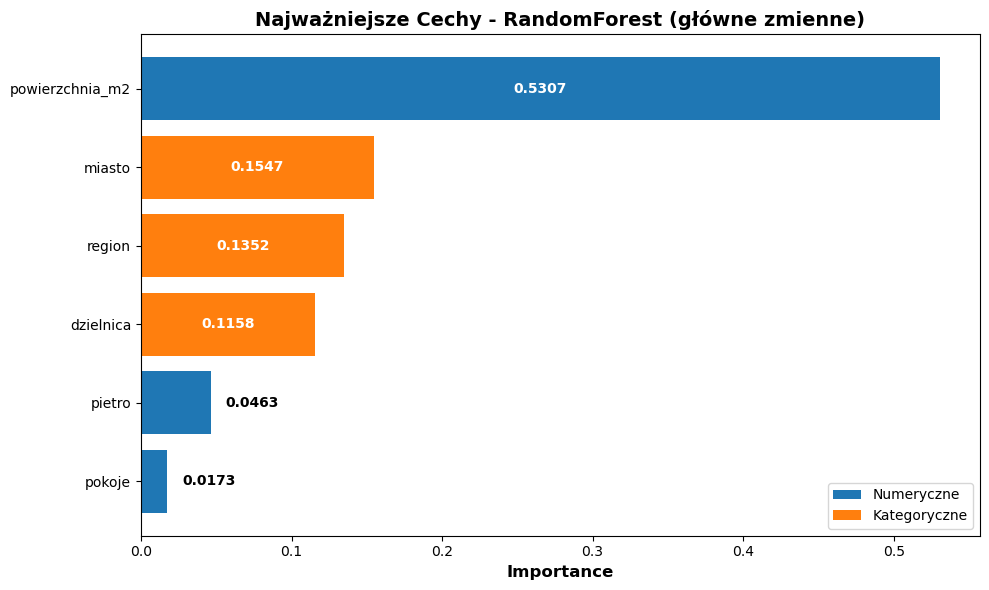

Waga po typie cechy
Cechy numeryczne:    0.5943 (59.4%)
Cechy kategoryczne:  0.4057 (40.6%)
Suma kontrolna:      1.0000


In [69]:
# Feature importance z głównymi cechami
model = final_pipeline.named_steps['model']
num_feature_names = num_cols
ohe = final_pipeline.named_steps['preprocess'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_cols_full)
all_feature_names = num_feature_names + list(cat_feature_names)

# Feature importance
importances = model.feature_importances_
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
})

agg_importance = {}

# Cechy numeryczne
for f in num_feature_names:
    agg_importance[f] = importance_df[importance_df['feature'] == f]['importance'].sum()

# Cechy kategoryczne
for cat in cat_cols_full:
    agg_importance[cat] = importance_df[
        importance_df['feature'].str.startswith(cat + '_')
    ]['importance'].sum()

agg_df = pd.DataFrame({
    'feature': list(agg_importance.keys()),
    'importance': list(agg_importance.values())
}).sort_values('importance', ascending=False)

# Kolory dla wykresu
colors = ['#1f77b4' if f in num_feature_names else '#ff7f0e' for f in agg_df['feature']]

# Wizualizacja z wartościami w środku lub obok barów
plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(agg_df)), agg_df['importance'], color=colors)

# Próg dla krótkiego bara (15% maksymalnej wartości)
max_importance = agg_df['importance'].max()
threshold = max_importance * 0.15

# Dodawanie wartości w środku lub obok barów
for i, (bar, value) in enumerate(zip(bars, agg_df['importance'])):
    width = bar.get_width()
    
    if width < threshold:
        # Krótki bar
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                 f'{value:.4f}',
                 ha='left', va='center', 
                 color='black', fontweight='bold', fontsize=10)
    else:
        # Długi bar
        plt.text(width/2, bar.get_y() + bar.get_height()/2, 
                 f'{value:.4f}',
                 ha='center', va='center', 
                 color='white', fontweight='bold', fontsize=10)

plt.yticks(range(len(agg_df)), agg_df['feature'])
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.title('Najważniejsze Cechy - RandomForest (główne zmienne)', fontsize=14, fontweight='bold')

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1f77b4', label='Numeryczne'),
    Patch(facecolor='#ff7f0e', label='Kategoryczne')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Suma importance po typie cechy
print("Waga po typie cechy")
num_importance = sum([agg_importance[f] for f in num_feature_names])
cat_importance = sum([agg_importance[f] for f in cat_cols_full])
print(f"Cechy numeryczne:    {num_importance:.4f} ({num_importance*100:.1f}%)")
print(f"Cechy kategoryczne:  {cat_importance:.4f} ({cat_importance*100:.1f}%)")

# Sprawdzenie sumy
total = num_importance + cat_importance
print(f"Suma kontrolna:      {total:.4f}")

Statystyki residuals

Średnia:    962.97 PLN
Std:        171,790.33 PLN
Min:        -1,717,865.04 PLN
Max:        1,601,646.11 PLN

Outliers (>2 sigma): 465 (5.2%)
Outliers (>3 sigma): 191 (2.1%)


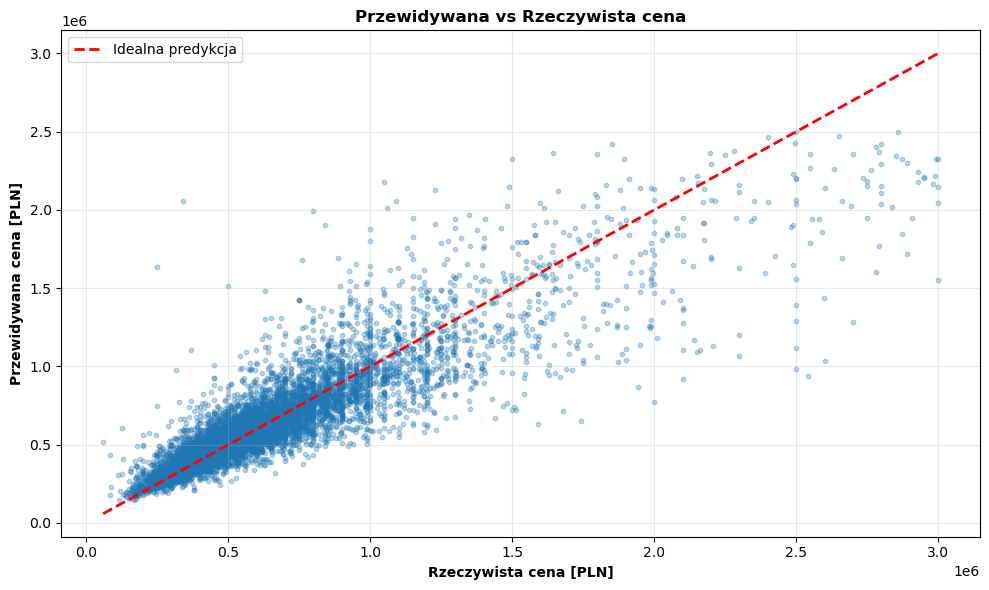

In [47]:
# Residual analysis (analiza błędów)

# Predykcje i residuals
y_pred = final_pipeline.predict(Xf_test)
residuals = yf_test.values - y_pred

# Statystyki residuals
print("Statystyki residuals\n")
print(f"Średnia:    {residuals.mean():,.2f} PLN")
print(f"Std:        {residuals.std():,.2f} PLN")
print(f"Min:        {residuals.min():,.2f} PLN")
print(f"Max:        {residuals.max():,.2f} PLN")

# Outliers
outliers_2sigma = (np.abs(residuals) > 2 * residuals.std()).sum()
outliers_3sigma = (np.abs(residuals) > 3 * residuals.std()).sum()
print(f"\nOutliers (>2 sigma): {outliers_2sigma} ({outliers_2sigma/len(residuals)*100:.1f}%)")
print(f"Outliers (>3 sigma): {outliers_3sigma} ({outliers_3sigma/len(residuals)*100:.1f}%)")

# Wykres: Przewidywana vs Rzeczywista cena
plt.figure(figsize=(10, 6))
plt.scatter(yf_test, y_pred, alpha=0.3, s=10)
plt.plot([yf_test.min(), yf_test.max()], 
         [yf_test.min(), yf_test.max()], 
         'r--', linewidth=2, label='Idealna predykcja')
plt.xlabel('Rzeczywista cena [PLN]', fontweight='bold')
plt.ylabel('Przewidywana cena [PLN]', fontweight='bold')
plt.title('Przewidywana vs Rzeczywista cena', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

MAE PO MIEŚCIE
miasto
gdynia         162925.768982
warszawa       147523.630719
gdansk         144741.795567
wroclaw        132143.606837
krakow         128247.101156
szczecin       106533.374082
poznan         105460.044860
katowice       102603.854303
bydgoszcz       95698.284252
olsztyn         95309.134547
torun           89352.600787
opole           88433.783747
radom           84397.014761
lodz            79453.351442
kielce          74581.590140
bialystok       72975.790897
lublin          66624.019646
rzeszow         63212.428114
czestochowa     55166.551325
sosnowiec       52618.922032

MAE PO REGIONIE
region
pomorskie              152273.924839
mazowieckie            132286.171695
dolnoslaskie           132143.606837
malopolskie            128247.101156
zachodniopomorskie     106533.374082
wielkopolskie          105460.044860
warminsko-mazurskie     95309.134547
kujawsko-pomorskie      93691.207199
opolskie                88433.783747
lodzkie                 79453.351442
swie

C:\Users\marci\AppData\Local\Temp\ipykernel_5272\3300703662.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_by_city = results_df.groupby('miasto')['abs_error'].mean().sort_values(ascending=False)
C:\Users\marci\AppData\Local\Temp\ipykernel_5272\3300703662.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_by_region = results_df.groupby('region')['abs_error'].mean().sort_values(ascending=False)


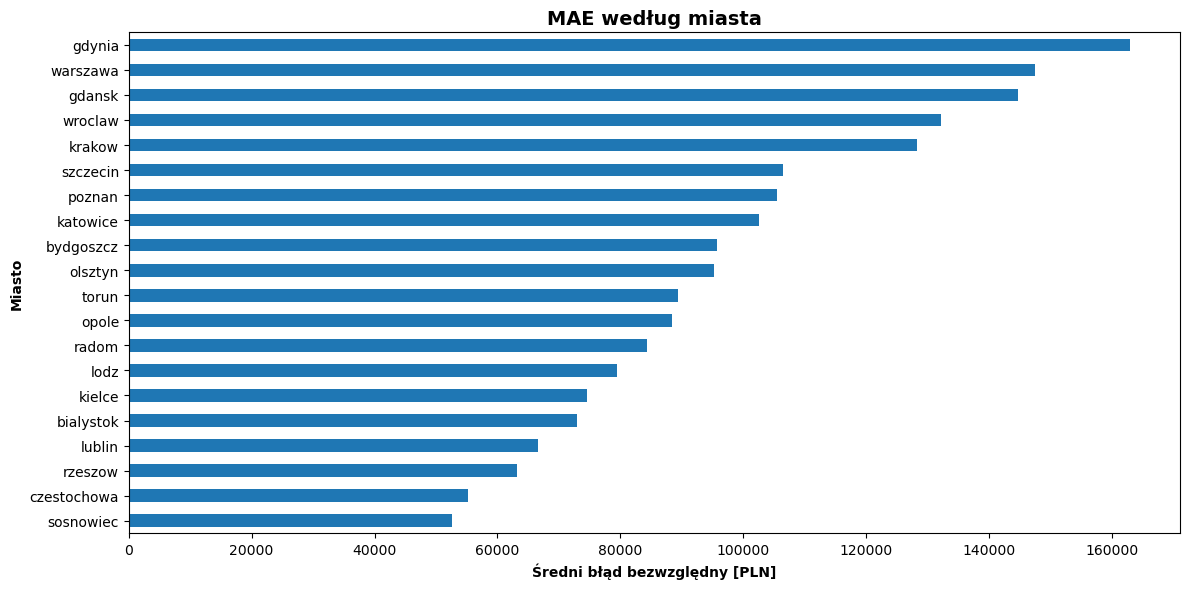

In [48]:
# Analiza miast i regionów

results_df = pd.DataFrame({
    'actual': yf_test.values,
    'predicted': y_pred,
    'abs_error': np.abs(residuals),
    'miasto': Xf_test['miasto'].values,
    'region': Xf_test['region'].values
})

# MAE per miasto
print("MAE PO MIEŚCIE")
mae_by_city = results_df.groupby('miasto')['abs_error'].mean().sort_values(ascending=False)
print(mae_by_city.to_string())

# MAE per region
print("\nMAE PO REGIONIE")
mae_by_region = results_df.groupby('region')['abs_error'].mean().sort_values(ascending=False)
print(mae_by_region.to_string())

In [65]:
# Przykładowe predykcje

# Losowe 10 przykładów
np.random.seed(42)
sample_indices = np.random.choice(len(yf_test), 10, replace=False)

comparison_df = pd.DataFrame({
    'Rzeczywista [PLN]': yf_test.iloc[sample_indices].values,
    'Przewidywana [PLN]': y_pred[sample_indices],
    'Błąd [PLN]': residuals[sample_indices],
    'Błąd [%]': (residuals[sample_indices] / yf_test.iloc[sample_indices].values * 100),
    'Pokoje': Xf_test.iloc[sample_indices]['pokoje'].values,
    'Powierzchnia [m²]': Xf_test.iloc[sample_indices]['powierzchnia_m2'].values,
    'Piętro': Xf_test.iloc[sample_indices]['pietro'].values,
    'Miasto': Xf_test.iloc[sample_indices]['miasto'].values,
    'Dzielnica': Xf_test.iloc[sample_indices]['dzielnica'].values
})

print("Przykładowe predykcje (10 losowych mieszkań)")
print(comparison_df.round(2).to_string(index=False))

Przykładowe predykcje (10 losowych mieszkań)
 Rzeczywista [PLN]  Przewidywana [PLN]  Błąd [PLN]  Błąd [%]  Pokoje  Powierzchnia [m²]  Piętro      Miasto      Dzielnica
            419850           419248.98      601.02      0.14       1              31.10       6      poznan    nowe miasto
            925000           786053.33   138946.67     15.02       2              51.50       5    warszawa        bielany
            614000           821445.23  -207445.23    -33.79       3              63.75       4      krakow  mistrzejowice
            409391           517988.71  -108597.71    -26.53       2              31.82       1      gdansk wrzeszcz gorny
            837505           583199.51   254305.49     30.36       4              62.10       1    katowice    srodmiescie
            684917           702729.57   -17812.57     -2.60       3              56.60       5     wroclaw         krzyki
            840000           570613.66   269386.34     32.07       3              57.00       

In [ ]:
# Finalny raport

# Timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Raport do pliku
report_filename = f"model_report_{timestamp}.txt"
with open(report_filename, 'w', encoding='utf-8') as f:
    f.write("\n")
    f.write("Raport końcowy dla CenoMetr\n")
    
    f.write(f"Data:     {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Model:    RandomForest Regressor\n")
    f.write(f"Encoder:  OneHotEncoder (dla dzielnic, miast, regionów)\n\n")
    
    # Dataset
    f.write("\n")
    f.write("Dataset\n")
    f.write("\n")
    f.write(f"Całkowita liczba mieszkań:     {len(df)}\n")
    f.write(f"Train set:                     {len(Xf_train)} (80%)\n")
    f.write(f"Test set:                      {len(Xf_test)} (20%)\n\n")
    
    # Features
    f.write("\n")
    f.write("Cechy modelu\n")
    f.write("\n")
    f.write("Numeryczne:\n")
    f.write("  - pokoje\n")
    f.write("  - powierzchnia_m2\n")
    f.write("  - pietro\n\n")
    f.write("Kategoryczne (OneHotEncoded):\n")
    f.write(f"  - dzielnica ({df['dzielnica'].nunique()} unikalnych)\n")
    f.write(f"  - miasto ({df['miasto'].nunique()} unikalnych)\n")
    f.write(f"  - region ({df['region'].nunique()} unikalnych)\n\n")
    
    # Hyperparametry
    f.write("\n")
    f.write("Najlepsze hiperparametry\n")
    f.write("\n")
    for param, value in rand_rf_full.best_params_.items():
        f.write(f"  {param}: {value}\n")
    f.write("\n")
    
    # Wyniki
    f.write("\n")
    f.write("Wyniki modelu na testowym secie\n")
    f.write("\n")
    f.write(f"R²:          {final_metrics['R2']:.4f}\n")
    f.write(f"RMSE:        {final_metrics['RMSE']:,.2f} PLN\n")
    f.write(f"MAE:         {final_metrics['MAE']:,.2f} PLN\n")
    f.write(f"MAPE:        {(final_metrics['MAE'] / yf_test.mean() * 100):.2f}%\n")
    f.write(f"CV MAE:      {-rand_rf_full.best_score_:,.2f} PLN\n\n")
    
    # Feature Importance
    f.write("\n")
    f.write("Feature importance\n")
    f.write("\n")
    for i, row in agg_df.iterrows():
        f.write(f"  {row['feature']:20s}: {row['importance']:.4f} ({row['importance']*100:.1f}%)\n")
    f.write("\n")
    
    # Residuals
    f.write("\n")
    f.write("Analiza błędów (Residuals)\n")
    f.write("\n")
    f.write(f"Średnia:         {residuals.mean():,.2f} PLN\n")
    f.write(f"Std:             {residuals.std():,.2f} PLN\n")
    f.write(f"Min:             {residuals.min():,.2f} PLN\n")
    f.write(f"Max:             {residuals.max():,.2f} PLN\n")
    f.write(f"Outliers (>2σ):  {outliers_2sigma} ({outliers_2sigma/len(residuals)*100:.1f}%)\n")
    f.write(f"Outliers (>3σ):  {outliers_3sigma} ({outliers_3sigma/len(residuals)*100:.1f}%)\n\n")
    
    # MAE per miasto (top 5 najgorsze)
    f.write("\n")
    f.write("MAE według miasta (top 5)\n")
    f.write("\n")
    for miasto, mae in mae_by_city.head(5).items():
        f.write(f"  {miasto:20s}: {mae:,.2f} PLN\n")
    f.write("\n")
    
    # Możliwości rozwoju
    f.write("\n")
    f.write("Możliwości rozwoju\n")
    f.write("\n")
    f.write("1. Dodanie nowych cech:\n")
    f.write("   - Odległość od morza (Trójmiasto)\n")
    f.write("   - Odległość od centrum miasta\n")
    f.write("   - Standard wykończenia (surowy/deweloperski/luksusowy)\n")
    f.write("   - Rok budowy budynku\n")
    f.write("   - Winda (tak/nie)\n")
    f.write("   - Parking/garaż\n")
    f.write("   - Balkon/taras (m²)\n")
    f.write("   - Widok (morze/park/rzeka)\n\n")
    f.write("2. Segmentacja modeli:\n")
    f.write("   - Osobny model dla Trójmiasta (Gdynia, Gdańsk)\n")
    f.write("   - Osobny model dla Warszawy\n")
    f.write("   - Osobny model dla rynku luksusowego (>1.5M PLN)\n\n")
    f.write("3. Inne algorytmy:\n")
    f.write("   - XGBoost\n")
    f.write("   - LightGBM\n")
    f.write("   - Ensemble (RF + HistGB + XGBoost)\n\n")
    
    # Podsumowanie
    f.write("\n")
    f.write("Podsumowanie\n")
    f.write("\n")
    f.write(f"Model RandomForest osiągnął R² = {final_metrics['R2']:.4f} i MAE = {final_metrics['MAE']:,.0f} PLN\n")
    f.write(f"na zbiorze testowym {len(Xf_test)} mieszkań.\n\n")
    f.write("Model działa najlepiej dla:\n")
    f.write("  - Małych i średnich miast (Sosnowiec, Częstochowa, Rzeszów)\n")
    f.write("  - Mieszkań o cenach <1M PLN\n")
    f.write("  - Standardowych lokalizacji\n\n")
    f.write("Model ma trudności z:\n")
    f.write("  - Trójmiastem (Gdynia, Gdańsk) - brak cechy 'odległość od morza'\n")
    f.write("  - Warszawą - duża złożoność dzielnic\n")
    f.write("  - Droższymi mieszkaniami (>1M) - brak cech jakościowych\n\n")
    f.write("\n")

print(f"\n Raport zapisany: {report_filename}")


✅ Raport zapisany: model_report_20260102_141450.txt
